# 03 — Engenharia de Features

**Objetivo:** Construir o `preprocessor` (ColumnTransformer com StandardScaler; `genero` descartado via `remainder='drop'`), gerar o split RAW e decidir o papel do PCA (variância uniforme → PCA só para visualização, não entra no clustering).

**Inputs:** `data/processed/dados_limpos.parquet`

**Outputs:** `features_scaled.parquet`, `features_2d_scaled.parquet`, `features_2d_scaled.parquet`, `preprocessor.pkl`, `pca_visualizacao.pkl`

---

**Roteiro:**

1. Setup, tema e configurações locais e globais
2. Carregamendo dos dados
3. Split treino/teste RAW (4 colunas) + persistência
4. Construção do preprocessor (ColumnTransformer)
5. Fit do preprocessor + PCA 2D/3D + variância explicada
6. Persistência dos artefatos
7. Fechamento

### Etapa 1 — Setup, tema e configurações locais e globais

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.config import CONFIG, CAMINHOS
from src.viz_config import PALETTE, CORES

DADOS_PRO   = CAMINHOS.dados_processed
MODELS_DIR  = CAMINHOS.modelos
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = CONFIG["dados"]["random_state"]
TEST_SIZE    = CONFIG["dados"]["test_size"]

print("✅ Setup OK\n")
print(f"DADOS_PRO   : {DADOS_PRO}")
print(f"MODELS_DIR  : {MODELS_DIR}")
print(f"RANDOM_STATE: {RANDOM_STATE}")

✅ Setup OK

DADOS_PRO   : C:\Users\jas_t\Repo\Portfolios\customer_segmentation_mall\data\processed
MODELS_DIR  : C:\Users\jas_t\Repo\Portfolios\customer_segmentation_mall\models
RANDOM_STATE: 42


### Etapa 2 - Carregamendo dos dados

In [2]:
df = pd.read_parquet(DADOS_PRO / "dados_limpos.parquet")

print(f"Shape: {df.shape[0]} linhas × {df.shape[1]} colunas\n")
df.head()

Shape: 200 linhas × 4 colunas



,genero,idade,renda_anual,score_gasto
id_cliente,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


### Etapa 3 — Split treino/teste RAW (4 colunas) + persistência

Para a etapa de clusterização, os dados foram divididos em conjuntos de treino e teste utilizando a função train_test_split() da biblioteca scikit-learn. 

- Diferentemente de problemas supervisionados, a segmentação de clientes não utiliza variável alvo (`y`). Dessa forma, a divisão foi realizada exclusivamente sobre as features disponíveis, sem aplicação de estratificação (`stratify`).
- O conjunto de entrada foi composto pelas quatro variáveis originais do dataset, incluindo a variável gênero, preservando as características brutas dos dados antes das transformações.
- A variável `genero` é descartada internamente pelo ColumnTransformer, por meio da configuração remainder='drop'.

In [3]:
X_completo = df.copy()

X_treino_raw, X_teste_raw = train_test_split(
    X_completo,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print("═" * 50)
print("SPLIT TREINO/TESTE (RAW)")
print("═" * 50)

print(f"   X_completo   : {X_completo.shape}")
print(f"   X_treino_raw : {X_treino_raw.shape}  ({len(X_treino_raw)/len(X_completo):.0%})")
print(f"   X_teste_raw  : {X_teste_raw.shape}  ({len(X_teste_raw)/len(X_completo):.0%})")

══════════════════════════════════════════════════
SPLIT TREINO/TESTE (RAW)
══════════════════════════════════════════════════
   X_completo   : (200, 4)
   X_treino_raw : (160, 4)  (80%)
   X_teste_raw  : (40, 4)  (20%)


In [4]:
print("═" * 50)
print("SANIDADE")
print("═" * 50)

sem_overlap = len(set(X_treino_raw.index) & set(X_teste_raw.index)) == 0
uniao_ok    = len(X_treino_raw) + len(X_teste_raw) == len(X_completo)
print(f"  {'✅' if sem_overlap else '❌'} treino e teste sem sobreposição de id_cliente")
print(f"  {'✅' if uniao_ok else '❌'} treino + teste = completo")

══════════════════════════════════════════════════
SANIDADE
══════════════════════════════════════════════════
  ✅ treino e teste sem sobreposição de id_cliente
  ✅ treino + teste = completo


In [5]:
X_treino_raw.to_parquet(DADOS_PRO / "X_treino_raw.parquet", index=True)
X_teste_raw.to_parquet(DADOS_PRO / "X_teste_raw.parquet",  index=True)

print(f"   data/processed/X_treino_raw.parquet  ({X_treino_raw.shape})")
print(f"   data/processed/X_teste_raw.parquet   ({X_teste_raw.shape})")

   data/processed/X_treino_raw.parquet  ((160, 4))
   data/processed/X_teste_raw.parquet   ((40, 4))


### Etapa 4 — Construção do preprocessor (ColumnTransformer)

In [6]:
COLS_NUMERICAS = ["idade", "renda_anual", "score_gasto"]
COLS_IGNORAR   = ["genero"]

print("═" * 75)
print("PAPÉIS DAS COLUNAS")
print("═" * 75)
print(f"   Escaladas (entram no KMeans) : {COLS_NUMERICAS}")
print(f"   Ignoradas (só perfilização)  : {COLS_IGNORAR}")

═══════════════════════════════════════════════════════════════════════════
PAPÉIS DAS COLUNAS
═══════════════════════════════════════════════════════════════════════════
   Escaladas (entram no KMeans) : ['idade', 'renda_anual', 'score_gasto']
   Ignoradas (só perfilização)  : ['genero']


As features numericas foram padronizadas utilizando `StandardScaler`, e posteriormente passadas pelo `ColumnTransformer` responsável por aplicar as transformações. Além disso, o ColumnTransformer foi configurado com `remainder='drop'`, fazendo com que variáveis não especificadas nas transformações fossem automaticamente removidas do conjunto final.

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), COLS_NUMERICAS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

preprocessor.set_output(transform="pandas")

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_na

### Etapa 5 — Fit do preprocessor + PCA 2D/3D + variância explicada

Primeiramente, vamos fazer o fit do preprocessor no dataset completo.

In [8]:
X_scaled = preprocessor.fit_transform(X_completo)

print("═" * 60)
print("PREPROCESSOR FITADO (dataset completo)")
print("═" * 60)
print(f"   Entrada : {X_completo.shape} (4 cols, genero incluído)")
print(f"   Saída   : {X_scaled.shape} (3 cols escaladas, genero descartado)")
print(f"   Colunas : {list(X_scaled.columns)}")
print(f"   Média ≈0 e desvio ≈1 após StandardScaler:")
print(X_scaled.describe().loc[["mean", "std"]].round(3))

════════════════════════════════════════════════════════════
PREPROCESSOR FITADO (dataset completo)
════════════════════════════════════════════════════════════
   Entrada : (200, 4) (4 cols, genero incluído)
   Saída   : (200, 3) (3 cols escaladas, genero descartado)
   Colunas : ['idade', 'renda_anual', 'score_gasto']
   Média ≈0 e desvio ≈1 após StandardScaler:
      idade  renda_anual  score_gasto
mean -0.000       -0.000       -0.000
std   1.003        1.003        1.003


Nesta etapa, o PCA foi ajustado utilizando três componentes principais, permitindo capturar a maior parte da variabilidade dos dados em um espaço de menor dimensão. A escolha por ajustar um único modelo `PCA(n_components=3)` traz uma vantagem prática: os dois primeiros componentes principais extraídos desse modelo são matematicamente idênticos aos que seriam obtidos em um `PCA(n_components=2)`.

In [9]:
pca = PCA(n_components=3, random_state=RANDOM_STATE)
coords_3d = pca.fit_transform(X_scaled)

var_ratio = pca.explained_variance_ratio_
var_cum = np.cumsum(var_ratio)

print("\n" + "═" * 52)
print("VARIÂNCIA EXPLICADA PELO PCA")
print("═" * 52)
for i, (vr, vc) in enumerate(zip(var_ratio, var_cum), start=1):
    print(f"   PC{i}: {vr:6.1%}  (acumulada: {vc:6.1%})")

print(f"\n   → PCA 2D retém {var_cum[1]:.1%} da variância")
print(f"   → PCA 3D retém {var_cum[2]:.1%} (rotação pura, 3 features)")


════════════════════════════════════════════════════
VARIÂNCIA EXPLICADA PELO PCA
════════════════════════════════════════════════════
   PC1:  44.3%  (acumulada:  44.3%)
   PC2:  33.3%  (acumulada:  77.6%)
   PC3:  22.4%  (acumulada: 100.0%)

   → PCA 2D retém 77.6% da variância
   → PCA 3D retém 100.0% (rotação pura, 3 features)


Vamos agora montar dois DataFrames com índice id_cliente preservado. 

In [10]:
features_2d = pd.DataFrame(coords_3d[:, :2],columns=["PC1", "PC2"], index=X_scaled.index)
features_2d.head()

,PC1,PC2
id_cliente,,
1,-0.615720,-1.763481
2,-1.665793,-1.820747
3,0.337862,-1.674799
4,-1.456573,-1.772430
5,-0.038465,-1.662740


In [11]:
features_3d = pd.DataFrame(coords_3d, columns=["PC1", "PC2", "PC3"], index=X_scaled.index)
features_3d.head()

,PC1,PC2,PC3
id_cliente,,,
1,-0.615720,-1.763481,-1.324232
2,-1.665793,-1.820747,-0.069952
3,0.337862,-1.674799,-2.179025
4,-1.456573,-1.772430,-0.078029
5,-0.038465,-1.662740,-0.687342


Vamos agora montar graáficos Scree plot + variância acumulada

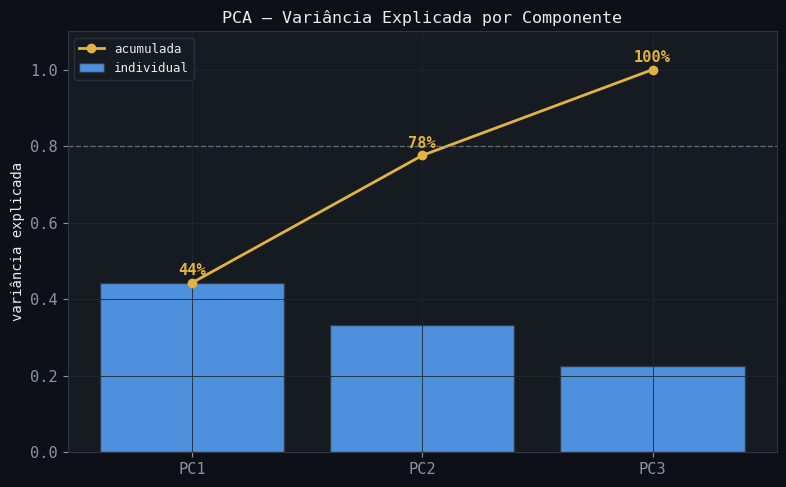

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

componentes = [f"PC{i}" for i in range(1, 4)]

ax.bar(componentes, var_ratio, color=PALETTE[0], alpha=0.85,
       edgecolor=CORES["borda"], label="individual")
ax.plot(componentes, var_cum, color=CORES["amarelo"], marker="o",
        linewidth=2, label="acumulada")

for i, vc in enumerate(var_cum):
    ax.text(i, vc + 0.02, f"{vc:.0%}", ha="center",
            color=CORES["amarelo"], fontweight="bold")
    
ax.axhline(0.80, color=CORES["texto2"], linestyle="--", linewidth=1, alpha=0.6)
ax.set_ylabel("variância explicada")
ax.set_title("PCA — Variância Explicada por Componente")
ax.set_ylim(0, 1.1)
ax.legend()

plt.tight_layout()
plt.savefig(CAMINHOS.figures / "nb03_pca_variancia.png", dpi=150, bbox_inches="tight")
plt.show()

O PCA 2D retém só 77.6% — abaixo da linha de 80%. Os 22.4% que o PC3 carrega não são ruído, são o `score_gasto` (ou parte dele) que ficaria de fora. Descartar PC3 antes do KMeans significaria clusterizar com quase um quarto da informação jogada fora. E o PCA 3D retém 100% justamente porque, com 3 features, ele é uma rotação pura — não reduz dimensão nenhuma, só gira os eixos.

### Etapa 6 — Persistência dos artefatos

In [13]:
X_scaled.to_parquet(DADOS_PRO / "features_scaled.parquet", index=True)
print("data/processed/")
print(f"  Features escaladas (3 colunas) -> Means")
print(f"    features_scaled.parquet     {X_scaled.shape}")

data/processed/
  Features escaladas (3 colunas) -> Means
    features_scaled.parquet     (200, 3)


In [14]:
features_2d.to_parquet(DADOS_PRO / "features_2d_scaled.parquet", index=True)
features_3d.to_parquet(DADOS_PRO / "features_3d_scaled.parquet", index=True)

print("data/processed/")
print("  Projeções PCA - Apenas para visualização")
print(f"   features_2d_scaled.parquet  {features_2d.shape}  → viz")
print(f"   features_2d_scaled.parquet   {features_3d.shape}  → viz")

data/processed/
  Projeções PCA - Apenas para visualização
   features_2d_scaled.parquet  (200, 2)  → viz
   features_2d_scaled.parquet   (200, 3)  → viz


In [15]:
joblib.dump(preprocessor, MODELS_DIR / "preprocessor.pkl")
joblib.dump(pca,          MODELS_DIR / "pca_visualizacao.pkl")

print("models/")
print("  Objetos sklearn")
print(f"   preprocessor.pkl        (referência/inspeção)")
print(f"   pca_visualizacao.pkl    (projeção p/ app)")

models/
  Objetos sklearn
   preprocessor.pkl        (referência/inspeção)
   pca_visualizacao.pkl    (projeção p/ app)


In [16]:
print("═" * 60)
print("Round-trip de sanidade")
print("═" * 60)

chk = pd.read_parquet(DADOS_PRO / "features_scaled.parquet")
print(f"   {'✅' if chk.index.name == 'id_cliente' else '❌'} índice preservado nos parquets")
print(f"   {'✅' if list(chk.columns) == COLS_NUMERICAS else '❌'} colunas corretas")

════════════════════════════════════════════════════════════
Round-trip de sanidade
════════════════════════════════════════════════════════════
   ✅ índice preservado nos parquets
   ✅ colunas corretas


### Etapa 7 — Fechamento

`PREPROCESSOR (ColumnTransformer)`
- StandardScaler nas 3 numéricas (idade, renda_anual, score_gasto)
- genero descartado via remainder='drop' (Opção A)
- set_output('pandas') → saída com nomes + índice id_cliente
- Fitado no dataset COMPLETO (coerência com pipeline_final)

`SPLITS RAW (4 colunas, genero incluído)`
- X_treino_raw (160) · X_teste_raw (40) · sem sobreposição
- Propósito: surrogate (NB05) + demonstração de inferência
- Sem stratify (clustering não tem target)

`DECISÃO DE ARQUITETURA — PCA`
- Variância: PC1 44% · PC2 33% · PC3 22% (features independentes)
- PCA 2D retém só 77.6% → descartaria sinal real
- DECISÃO: pipeline_final = preprocessor → KMeans (3 features, 100%)
- PCA = só visualização (2D/3D), nunca alimenta o KMeans
- Justificativa: 3 features independentes não pedem redução

`ARTEFATOS`
- data/processed/
    - features_scaled.parquet (200×3) → entrada do KMeans
    - features_2d_scaled.parquet · features_3d_scaled.parquet → viz
- models/
    - preprocessor.pkl (referência) · pca_visualizacao.pkl (app)

`PRÓXIMO PASSO → NB04 (Modelagem)`
- Escolha de k: método do cotovelo (inércia) + silhouette por k
- Montar pipeline_final = preprocessor → KMeans (do zero, fit no completo)
- Salvar pipeline_final.joblib (artefato único de deploy)